# 퍼실님의 버그 해결
## 버그 수정

정답 파일 분석 결과 두 가지 치명적 버그 발견. 맨 아래에 수정 코드 추가함.

## 버그 1. masked_fill(mask == 0, -1e9) — 마스크 반전

패딩 마스크는 PAD 위치가 1, 유효 토큰이 0인데  
masked_fill(mask == 0, -1e9) 로 쓰면 유효 토큰(0)을 전부 -inf 처리해버림.  
결과적으로 PAD 토큰한테만 attention이 가는 완전히 뒤집힌 동작.

### 버그 2. cross-attention에 causal mask 투입

generate_masks()에서 dec_enc_causality_mask를 만들어서 cross-attention에 넘김.  
번역은 어순이 바뀌기 때문에 디코더는 인코더 출력 전체를 자유롭게 봐야 함.  
cross-attention에 causal mask 넣으면 앞쪽 인코더 토큰을 못 보게 되고,  
버그 1(마스크 반전)까지 겹치면 마지막 토큰은 attend할 게 없어서 NaN 발생.

# Step 1. 라이브러리와 디바이스

In [1]:
import os, re, math, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__, "| device:", device)


torch: 2.7.1+cu118 | device: cuda


# Step 2. 데이터 경로 설정

이미 ~/work/transformer/data 에 korean-english-park.train.ko 와 .en 이 있으므로 다운로드는 생략한다.


In [2]:
HOME = os.getenv("HOME")
DATA_DIR = os.path.join(HOME, "work/transformer/data")

KOR_PATH = os.path.join(DATA_DIR, "korean-english-park.train.ko")
ENG_PATH = os.path.join(DATA_DIR, "korean-english-park.train.en")

print("DATA_DIR:", DATA_DIR)
print("kor:", os.path.exists(KOR_PATH), "eng:", os.path.exists(ENG_PATH))


DATA_DIR: /home/jovyan/work/transformer/data
kor: True eng: True


# Step 3. 정제와 토크나이저

- 중복 제거하고 병렬 쌍 유지
- 소문자화, 특수문자 정리, 문장부호 분리
- SentencePiece 토크나이저 학습 (한/영 각각 8000 vocab)


In [3]:
def preprocess_sentence(sentence: str) -> str:
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r"[^a-zA-Z가-힣?.!,]+", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence

def load_pairs(kor_path, eng_path):
    with open(kor_path, "r") as f: kor = f.read().splitlines()
    with open(eng_path, "r") as f: eng = f.read().splitlines()
    assert len(kor) == len(eng)
    seen, pairs = set(), []
    for k, e in zip(kor, eng):
        key = k + "\t" + e
        if key in seen:
            continue
        seen.add(key)
        pairs.append((preprocess_sentence(k), preprocess_sentence(e)))
    return pairs

pairs = load_pairs(KOR_PATH, ENG_PATH)
print(f"중복 제거 후 병렬쌍: {len(pairs):,}")
print("예시:", pairs[0])

kor_corpus = [k for k, _ in pairs]
eng_corpus = [e for _, e in pairs]


중복 제거 후 병렬쌍: 78,968
예시: ('개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?', 'much of personal computing is about can you top this ?')


In [4]:
import sentencepiece as spm

SRC_VOCAB_SIZE = 8000
TGT_VOCAB_SIZE = 8000

def generate_tokenizer(corpus, vocab_size, lang,
                       pad_id=0, bos_id=1, eos_id=2, unk_id=3):
    txt_path = f"./{lang}_corpus.txt"
    model_prefix = f"./{lang}_spm"
    with open(txt_path, "w") as f:
        for row in corpus:
            f.write(row + "\n")

    # 원본 코드는 공백 누락 + '--pad_id==%d' (등호 두 개) 로 학습이 깨졌음
    spm.SentencePieceTrainer.Train(
        f"--input={txt_path} --model_prefix={model_prefix} "
        f"--vocab_size={vocab_size} --character_coverage=0.9995 "
        f"--model_type=bpe "
        f"--pad_id={pad_id} --bos_id={bos_id} --eos_id={eos_id} --unk_id={unk_id}"
    )
    tk = spm.SentencePieceProcessor()
    tk.Load(f"{model_prefix}.model")
    return tk

print("토크나이저 학습 중...")
ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")
en_tokenizer.set_encode_extra_options("bos:eos")

PAD_ID, BOS_ID, EOS_ID, UNK_ID = 0, 1, 2, 3
print("ko vocab:", ko_tokenizer.get_piece_size(),
      "en vocab:", en_tokenizer.get_piece_size())
print("샘플 인코딩:", en_tokenizer.encode_as_pieces("hello world"))


토크나이저 학습 중...


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=./ko_corpus.txt --model_prefix=./ko_spm --vocab_size=8000 --character_coverage=0.9995 --model_type=bpe --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ./ko_corpus.txt
  input_format: 
  model_prefix: ./ko_spm
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_voca

ko vocab: 8000 en vocab: 8000
샘플 인코딩: ['<s>', '▁hel', 'lo', '▁world', '</s>']


10661485
trainer_interface.cc(552) LOG(INFO) Done: 99.9909% characters are covered.
trainer_interface.cc(562) LOG(INFO) Alphabet size=29
trainer_interface.cc(563) LOG(INFO) Final character coverage=0.999909
trainer_interface.cc(594) LOG(INFO) Done! preprocessed 78956 sentences.
trainer_interface.cc(600) LOG(INFO) Tokenizing input sentences with whitespace: 78956
trainer_interface.cc(611) LOG(INFO) Done! 44562
bpe_model_trainer.cc(159) LOG(INFO) Updating active symbols. max_freq=269076 min_freq=1
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=76902 size=20 all=1388 active=1358 piece=at
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=41118 size=40 all=2518 active=2488 piece=id
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=21998 size=60 all=3739 active=3709 piece=ut
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=16676 size=80 all=5227 active=5197 piece=ver
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=12810 size=100 all=6217 active=6187 piece=▁al
bpe_model_trainer.cc(159) LOG(INFO) 

# Step 4. 텐서화

길이 40 이하 문장만 학습에 사용한다. 영어 쪽은 bos/eos 포함이라 최소 길이 3 으로 둔다.


In [5]:
MAX_LEN = 40

src_corpus, tgt_corpus = [], []
for k, e in zip(kor_corpus, eng_corpus):
    s = ko_tokenizer.encode_as_ids(k)
    t = en_tokenizer.encode_as_ids(e)  # bos/eos 포함
    if 1 <= len(s) <= MAX_LEN and 3 <= len(t) <= MAX_LEN:
        src_corpus.append(torch.tensor(s, dtype=torch.long))
        tgt_corpus.append(torch.tensor(t, dtype=torch.long))

print(f"학습용 병렬쌍: {len(src_corpus):,}")
print("src 예시 len:", len(src_corpus[0]), "tgt 예시 len:", len(tgt_corpus[0]))


학습용 병렬쌍: 58,876
src 예시 len: 16 tgt 예시 len: 15


# Step 5. 모델 구성

마스크 컨벤션을 True == 가려라 하나로 통일하고, attention 내부에서 masked_fill(mask, -inf) 로 처리한다.
이전 코드는 mask == 0 위치를 가려서 유효 토큰이 전부 -inf 가 되는 치명적 버그가 있었다.


In [6]:
def positional_encoding(pos_len, d_model):
    pe = np.zeros((pos_len, d_model), dtype=np.float32)
    position = np.arange(0, pos_len)[:, None]
    div_term = np.exp(np.arange(0, d_model, 2) * -(math.log(10000.0) / d_model))
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)
    return torch.from_numpy(pe)


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)
        self.attn_dropout = nn.Dropout(dropout)

    def _split(self, x):
        b, t, _ = x.shape
        return x.view(b, t, self.num_heads, self.depth).transpose(1, 2)

    def _combine(self, x):
        b, h, t, d = x.shape
        return x.transpose(1, 2).contiguous().view(b, t, h * d)

    def forward(self, Q, K, V, mask=None):
        Q = self._split(self.W_q(Q))
        K = self._split(self.W_k(K))
        V = self._split(self.W_v(V))

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.depth)
        if mask is not None:
            scores = scores.masked_fill(mask, float("-inf"))
        attn = F.softmax(scores, dim=-1)
        attn = self.attn_dropout(attn)
        out = torch.matmul(attn, V)
        out = self._combine(out)
        return self.linear(out), attn


class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.w_2(self.dropout(F.gelu(self.w_1(x))))


class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff, dropout)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask):
        h = self.norm_1(x)
        h, attn = self.self_attn(h, h, h, src_mask)
        x = x + self.dropout(h)

        h = self.norm_2(x)
        x = x + self.dropout(self.ffn(h))
        return x, attn


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff, dropout)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, tgt_mask, memory_mask):
        h = self.norm_1(x)
        h, self_attn = self.self_attn(h, h, h, tgt_mask)
        x = x + self.dropout(h)

        h = self.norm_2(x)
        # cross-attention 에는 인코더 패딩 마스크만 (causal X)
        h, cross_attn = self.cross_attn(h, enc_out, enc_out, memory_mask)
        x = x + self.dropout(h)

        h = self.norm_3(x)
        x = x + self.dropout(self.ffn(h))
        return x, self_attn, cross_attn


class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, src_mask):
        attns = []
        for layer in self.layers:
            x, a = layer(x, src_mask)
            attns.append(a)
        return x, attns


class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, tgt_mask, memory_mask):
        self_attns, cross_attns = [], []
        for layer in self.layers:
            x, sa, ca = layer(x, enc_out, tgt_mask, memory_mask)
            self_attns.append(sa); cross_attns.append(ca)
        return x, self_attns, cross_attns


class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.1, shared=True):
        super().__init__()
        self.d_model = d_model
        self.shared = shared

        self.enc_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=0)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model, padding_idx=0)
        self.register_buffer("pos_encoding", positional_encoding(pos_len, d_model))
        self.dropout = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size, bias=False)
        if shared:
            self.fc.weight = self.dec_emb.weight

        self._reset_parameters()

    def _reset_parameters(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def _embed(self, emb, x):
        # shared 여부와 무관하게 항상 sqrt(d_model) 스케일
        out = emb(x) * math.sqrt(self.d_model)
        out = out + self.pos_encoding[: x.size(1)].unsqueeze(0)
        return self.dropout(out)

    def forward(self, src, tgt, src_mask, tgt_mask, memory_mask):
        enc_in = self._embed(self.enc_emb, src)
        dec_in = self._embed(self.dec_emb, tgt)

        enc_out, enc_attns = self.encoder(enc_in, src_mask)
        dec_out, dec_attns, cross_attns = self.decoder(
            dec_in, enc_out, tgt_mask, memory_mask
        )
        return self.fc(dec_out), enc_attns, dec_attns, cross_attns


print("모델 클래스 정의 완료")


모델 클래스 정의 완료


# 마스킹

마스크는 bool 텐서, True == 가려라 컨벤션이다.

- src_mask: 인코더 self-attn, 키의 PAD 위치만 가림. shape [B, 1, 1, Ts]
- tgt_mask: 디코더 self-attn, 키의 PAD + 미래 위치를 가림. shape [B, 1, Tt, Tt]
- memory_mask: 디코더 cross-attn, 인코더 패딩만 가림 (causal 없음). shape [B, 1, 1, Ts]


In [7]:
def padding_mask(seq):
    return (seq == 0).unsqueeze(1).unsqueeze(2)

def causal_mask(size, device):
    m = torch.triu(torch.ones(size, size, dtype=torch.bool, device=device), diagonal=1)
    return m.unsqueeze(0).unsqueeze(0)

def generate_masks(src, tgt):
    src_pad = padding_mask(src)
    tgt_pad = padding_mask(tgt)
    tgt_causal = causal_mask(tgt.size(1), tgt.device)
    tgt_mask = tgt_pad | tgt_causal
    memory_mask = src_pad
    return src_pad, tgt_mask, memory_mask


# Step 6. 하이퍼파라미터와 모델 인스턴스화

In [8]:
N_LAYERS = 4
D_MODEL  = 256
N_HEADS  = 8
D_FF     = 1024
DROPOUT  = 0.1
POS_LEN  = MAX_LEN + 2
BATCH_SIZE = 128
EPOCHS = 20
WARMUP_STEPS = 4000
LABEL_SMOOTH = 0.1

model = Transformer(
    n_layers=N_LAYERS, d_model=D_MODEL, n_heads=N_HEADS, d_ff=D_FF,
    src_vocab_size=SRC_VOCAB_SIZE, tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=POS_LEN, dropout=DROPOUT, shared=True,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"파라미터 수: {n_params/1e6:.2f}M")


파라미터 수: 11.47M


# Step 7. Optimizer / Scheduler / Loss

원논문 Noam 스케줄을 LambdaLR 로 구현한다.


In [9]:
def noam_lr(d_model, warmup):
    def lr(step):
        step = max(1, step)
        return (d_model ** -0.5) * min(step ** -0.5, step * warmup ** -1.5)
    return lr

optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)
scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=noam_lr(D_MODEL, WARMUP_STEPS))


class LabelSmoothingLoss(nn.Module):
    def __init__(self, vocab_size, pad_id=0, smoothing=0.1):
        super().__init__()
        self.vocab_size = vocab_size
        self.pad_id = pad_id
        self.smoothing = smoothing

    def forward(self, logits, target):
        logp = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            true_dist = torch.full_like(logp, self.smoothing / (self.vocab_size - 2))
            true_dist.scatter_(-1, target.unsqueeze(-1), 1.0 - self.smoothing)
            true_dist[:, :, self.pad_id] = 0
            mask = (target != self.pad_id).unsqueeze(-1)
            true_dist = true_dist * mask
        loss = -(true_dist * logp).sum(dim=-1)
        n_tok = (target != self.pad_id).sum().clamp(min=1)
        return loss.sum() / n_tok


criterion = LabelSmoothingLoss(TGT_VOCAB_SIZE, pad_id=PAD_ID, smoothing=LABEL_SMOOTH)
print("optimizer / scheduler / loss 준비 완료")


optimizer / scheduler / loss 준비 완료


# Step 8. 미니배치 패딩과 학습 루프

전체 텐서를 미리 한꺼번에 패딩하면 가장 긴 문장 길이까지 모든 시퀀스가 늘어나서 메모리/속도가 나빠진다.
배치 단위로만 패딩해서 학습한다.


In [10]:
from torch.nn.utils.rnn import pad_sequence

train_idx = list(range(len(src_corpus)))

def make_batch(indices):
    src = pad_sequence([src_corpus[i] for i in indices], batch_first=True, padding_value=PAD_ID)
    tgt = pad_sequence([tgt_corpus[i] for i in indices], batch_first=True, padding_value=PAD_ID)
    return src.to(device), tgt.to(device)


def train_step(src, tgt):
    tgt_in  = tgt[:, :-1]
    tgt_out = tgt[:, 1:]

    src_mask, tgt_mask, memory_mask = generate_masks(src, tgt_in)

    optimizer.zero_grad()
    logits, *_ = model(src, tgt_in, src_mask, tgt_mask, memory_mask)
    loss = criterion(logits, tgt_out)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()
    return loss.item()


In [11]:
print(f"학습 시작: {EPOCHS} epochs, batch={BATCH_SIZE}, 데이터 {len(src_corpus):,} 문장")
t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    model.train()
    random.shuffle(train_idx)
    total, n = 0.0, 0
    for s in range(0, len(train_idx), BATCH_SIZE):
        batch = train_idx[s : s + BATCH_SIZE]
        if not batch:
            continue
        src, tgt = make_batch(batch)
        loss = train_step(src, tgt)
        total += loss; n += 1
    print(f"Epoch {epoch:2d} | avg loss {total/max(1,n):.4f} | "
          f"lr {scheduler.get_last_lr()[0]:.2e} | "
          f"elapsed {time.time()-t0:.1f}s")


학습 시작: 20 epochs, batch=128, 데이터 58,876 문장
Epoch  1 | avg loss 7.4406 | lr 1.14e-04 | elapsed 59.3s
Epoch  2 | avg loss 6.4932 | lr 2.27e-04 | elapsed 119.9s
Epoch  3 | avg loss 5.9177 | lr 3.41e-04 | elapsed 180.4s
Epoch  4 | avg loss 5.5581 | lr 4.55e-04 | elapsed 240.8s
Epoch  5 | avg loss 5.2538 | lr 5.68e-04 | elapsed 301.2s
Epoch  6 | avg loss 5.0109 | lr 6.82e-04 | elapsed 361.8s
Epoch  7 | avg loss 4.8241 | lr 7.96e-04 | elapsed 422.4s
Epoch  8 | avg loss 4.6736 | lr 9.09e-04 | elapsed 482.9s
Epoch  9 | avg loss 4.5519 | lr 9.71e-04 | elapsed 543.5s
Epoch 10 | avg loss 4.4071 | lr 9.22e-04 | elapsed 604.0s
Epoch 11 | avg loss 4.2629 | lr 8.79e-04 | elapsed 664.6s
Epoch 12 | avg loss 4.1370 | lr 8.41e-04 | elapsed 725.2s
Epoch 13 | avg loss 4.0276 | lr 8.08e-04 | elapsed 785.7s
Epoch 14 | avg loss 3.9332 | lr 7.79e-04 | elapsed 846.3s
Epoch 15 | avg loss 3.8503 | lr 7.52e-04 | elapsed 906.7s
Epoch 16 | avg loss 3.7768 | lr 7.29e-04 | elapsed 967.3s
Epoch 17 | avg loss 3.7111 | l

# Step 9. 번역 함수 (Greedy decoding)

- model.eval() + torch.no_grad()
- 디바이스 이동
- unk 강제 회피
- 최대 길이 cap


In [12]:
@torch.no_grad()
def evaluate(sentence, max_len=MAX_LEN):
    model.eval()

    sent = preprocess_sentence(sentence)
    src_ids = ko_tokenizer.encode_as_ids(sent)
    src = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(0)

    out = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)
    generated = []
    enc_attns = dec_attns = cross_attns = None

    for _ in range(max_len):
        src_mask, tgt_mask, memory_mask = generate_masks(src, out)
        logits, enc_attns, dec_attns, cross_attns = model(
            src, out, src_mask, tgt_mask, memory_mask
        )
        next_logits = logits[0, -1].clone()
        next_logits[UNK_ID] = float("-inf")
        next_id = int(torch.argmax(next_logits).item())

        if next_id == EOS_ID:
            break
        generated.append(next_id)
        out = torch.cat(
            [out, torch.tensor([[next_id]], device=device)], dim=-1
        )

    return en_tokenizer.decode_ids(generated), enc_attns, dec_attns, cross_attns


def translate(sentence):
    result, *_ = evaluate(sentence)
    return result


# Step 10. 번역 예시

In [13]:
examples = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
    "그는 어제 학교에 갔다.",
    "한국은 아름다운 나라이다.",
    "정부는 새로운 정책을 발표했다.",
    "경제는 빠르게 성장하고 있다.",
    "그녀는 영어를 매우 잘한다.",
    "내일 비가 올 것 같다.",
]

print("=" * 70)
print(" Korean -> English Translations")
print("=" * 70)
for i, s in enumerate(examples, 1):
    out = translate(s)
    print(f"{i:2d}. KO: {s}")
    print(f"    EN: {out}")
    print("-" * 70)

print()
print("Hyperparameters")
print(f"  n_layers={N_LAYERS}, d_model={D_MODEL}, n_heads={N_HEADS}, "
      f"d_ff={D_FF}, dropout={DROPOUT}")
print(f"  vocab(src/tgt)={SRC_VOCAB_SIZE}/{TGT_VOCAB_SIZE}, "
      f"max_len={MAX_LEN}, warmup={WARMUP_STEPS}, "
      f"label_smooth={LABEL_SMOOTH}, batch={BATCH_SIZE}, epochs={EPOCHS}")


 Korean -> English Translations
 1. KO: 오바마는 대통령이다.
    EN: obama is the president .
----------------------------------------------------------------------
 2. KO: 시민들은 도시 속에 산다.
    EN: the city is in the town of sir .
----------------------------------------------------------------------
 3. KO: 커피는 필요 없다.
    EN: it s not just coffee .
----------------------------------------------------------------------
 4. KO: 일곱 명의 사망자가 발생했다.
    EN: seven people were killed in the disaster .
----------------------------------------------------------------------
 5. KO: 그는 어제 학교에 갔다.
    EN: he was later sworn in the school .
----------------------------------------------------------------------
 6. KO: 한국은 아름다운 나라이다.
    EN: south korea is beautiful in the beautiful country .
----------------------------------------------------------------------
 7. KO: 정부는 새로운 정책을 발표했다.
    EN: the government has set a new policy to set a new government .
-------------------------------------------------------

#### 우와.....

# Step 10. 어텐션 시각화

입력: 오바마는 대통령이다.
번역: obama is the president .



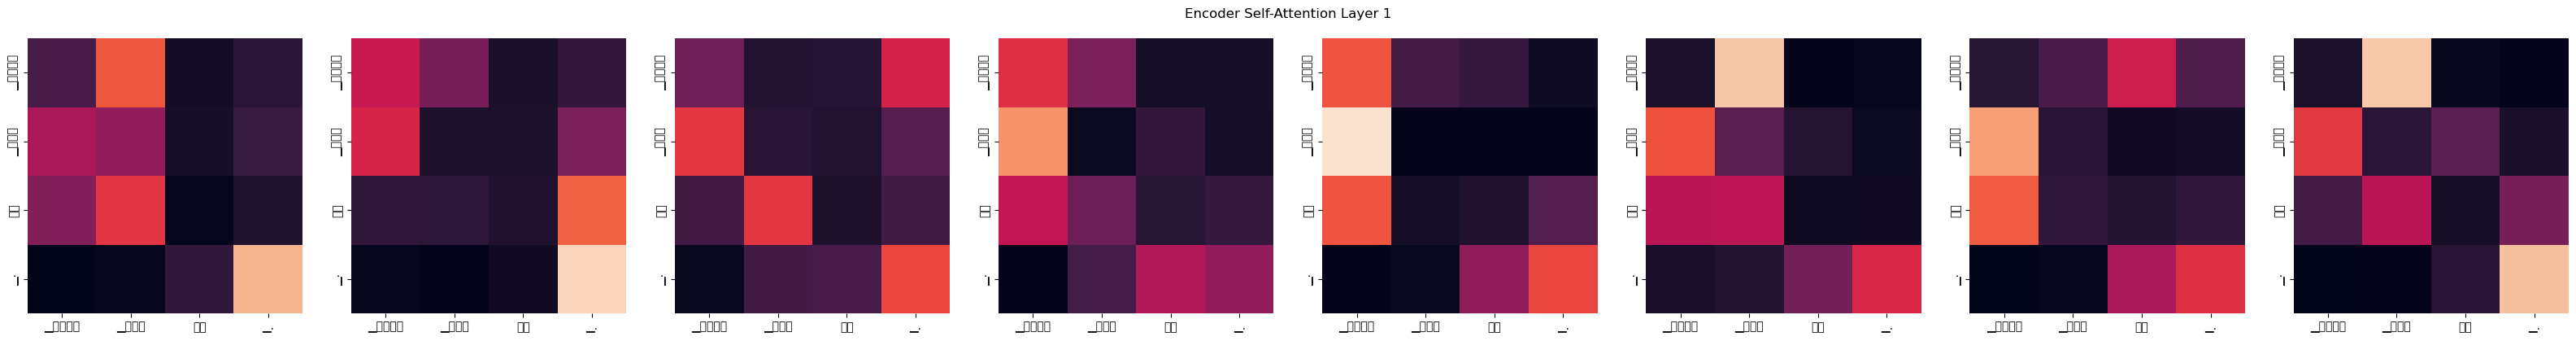

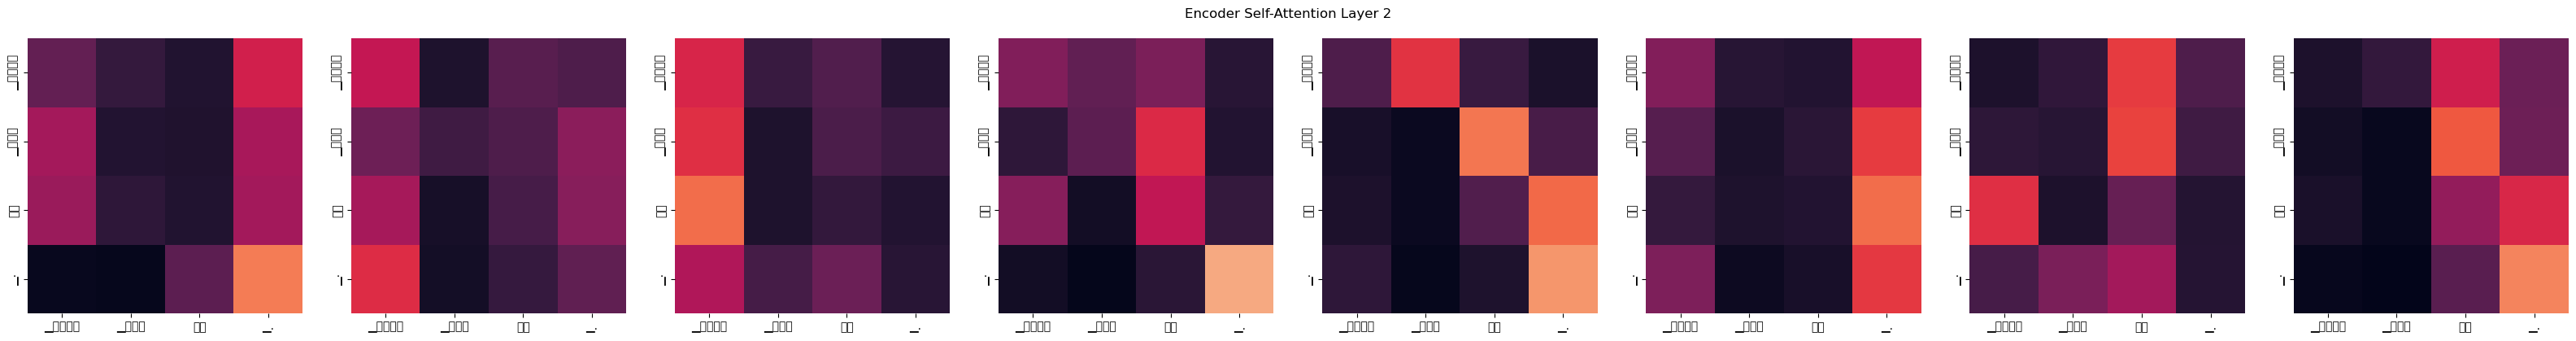

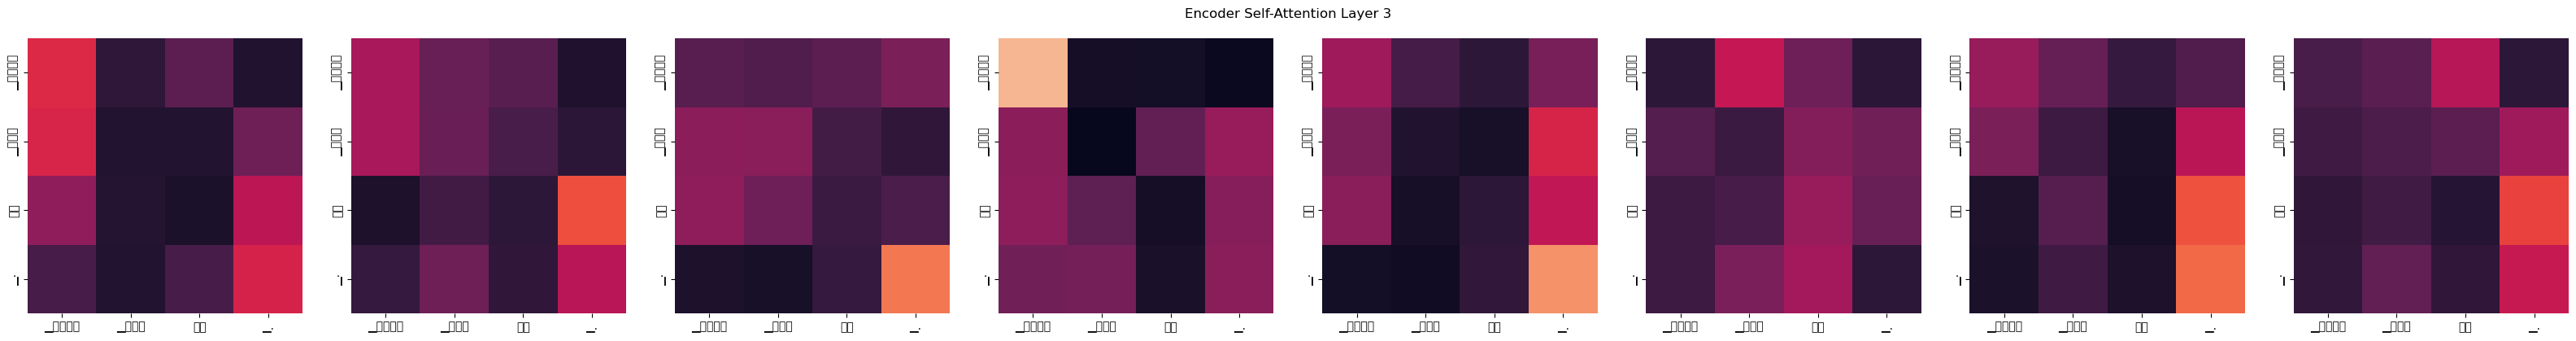

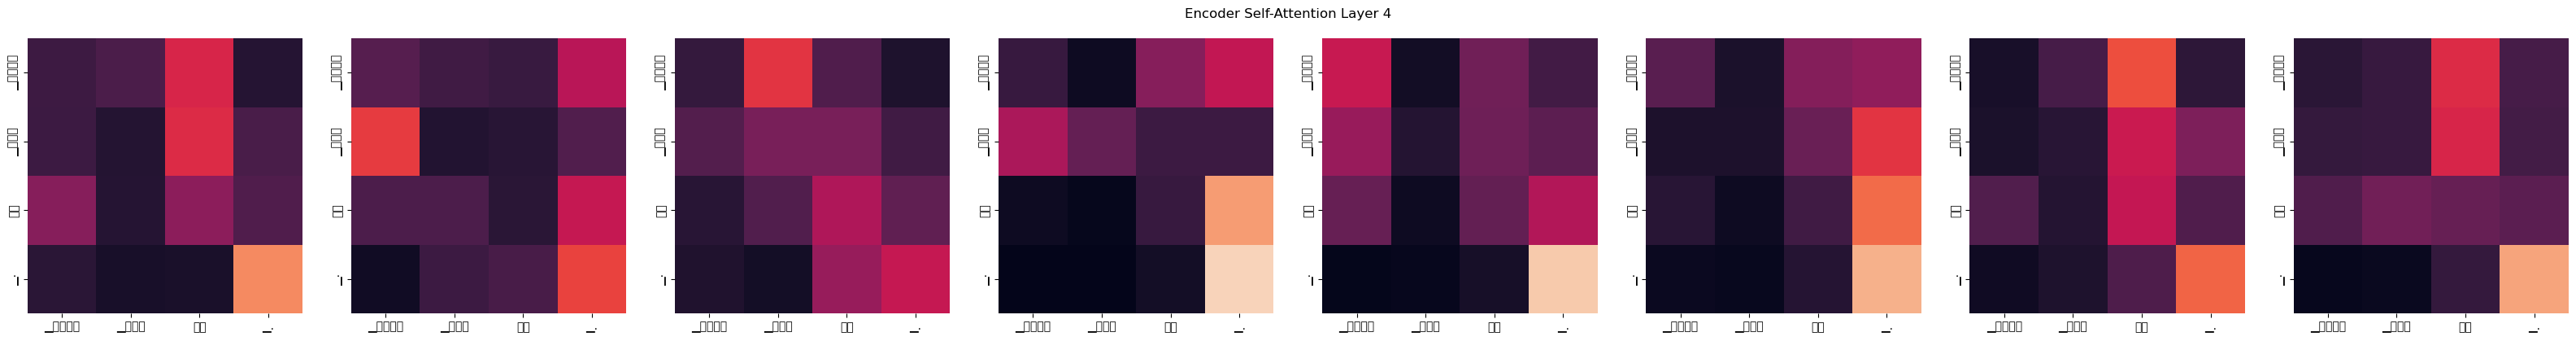

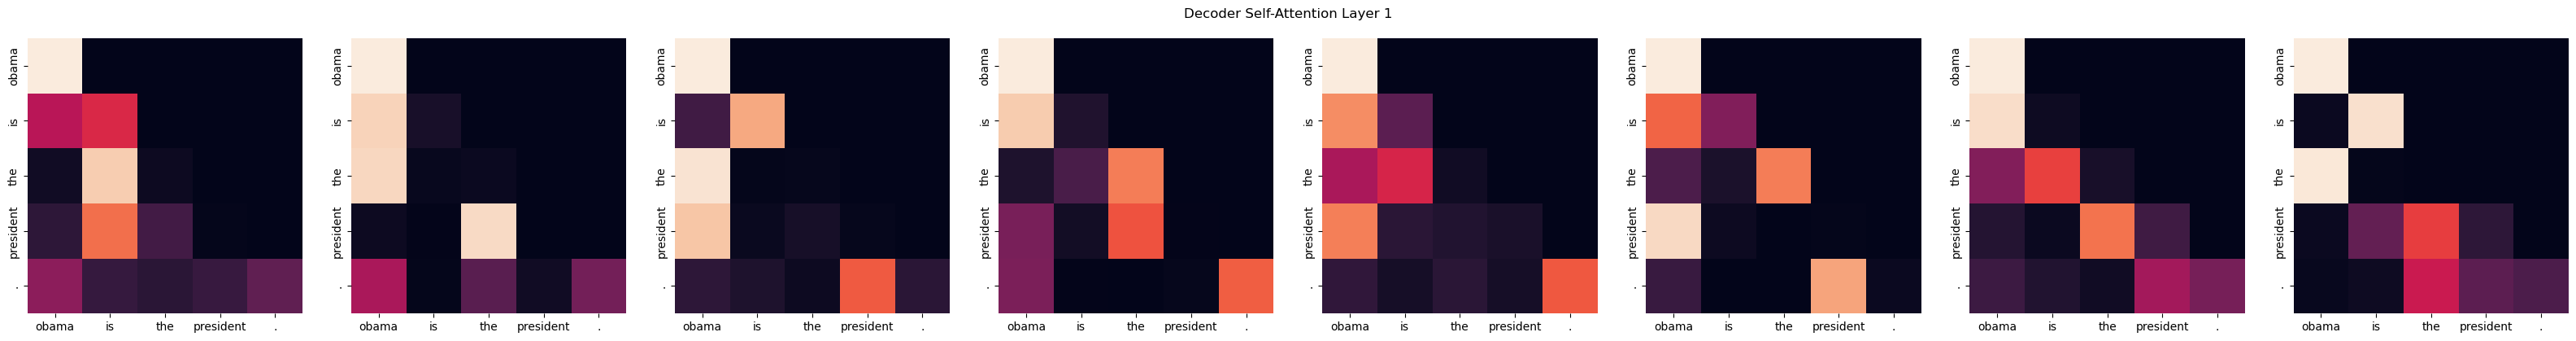

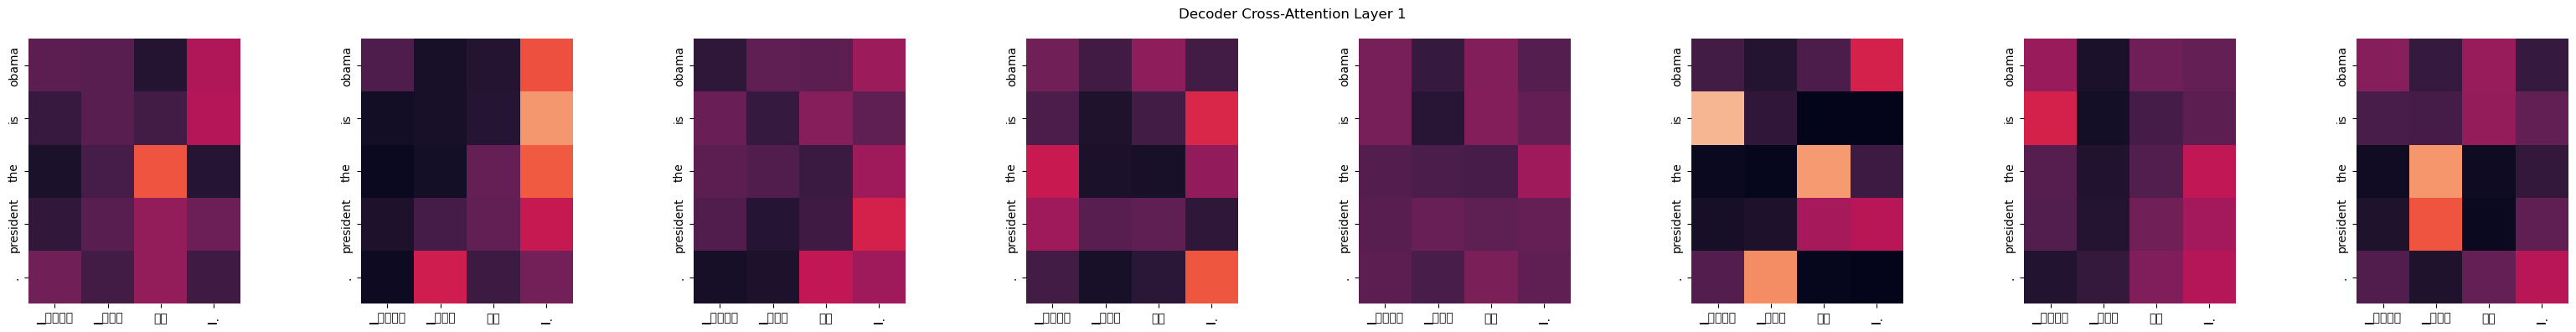

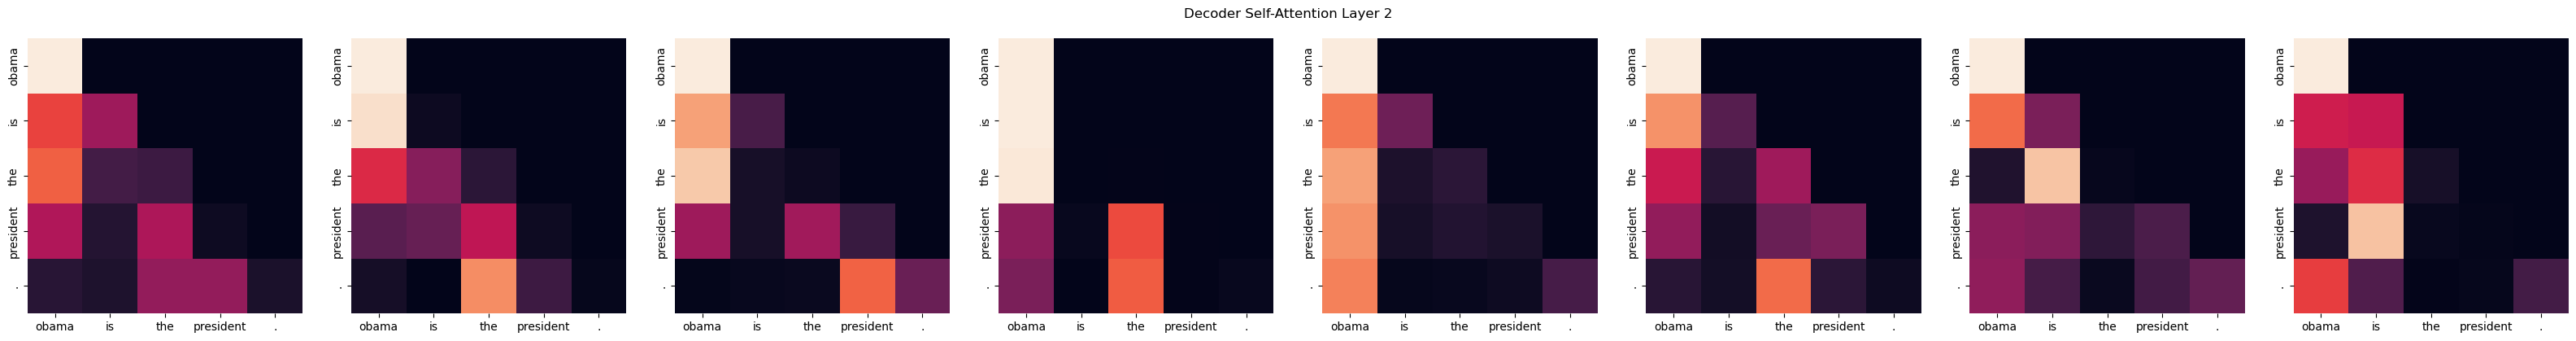

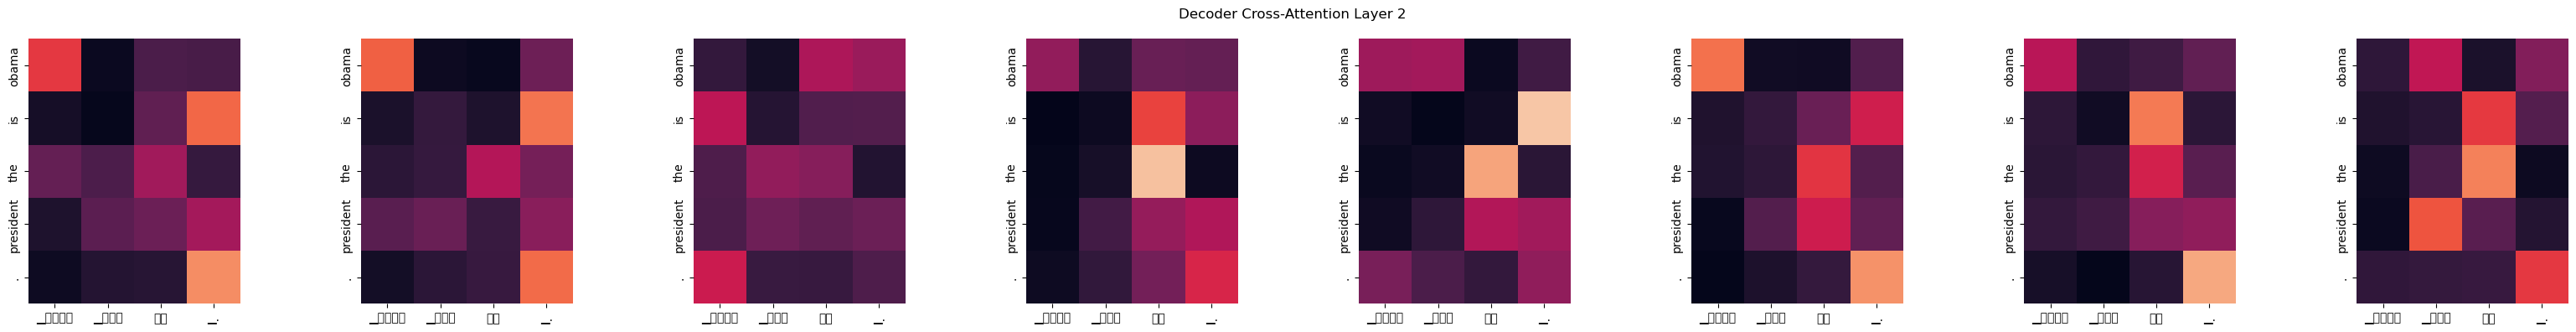

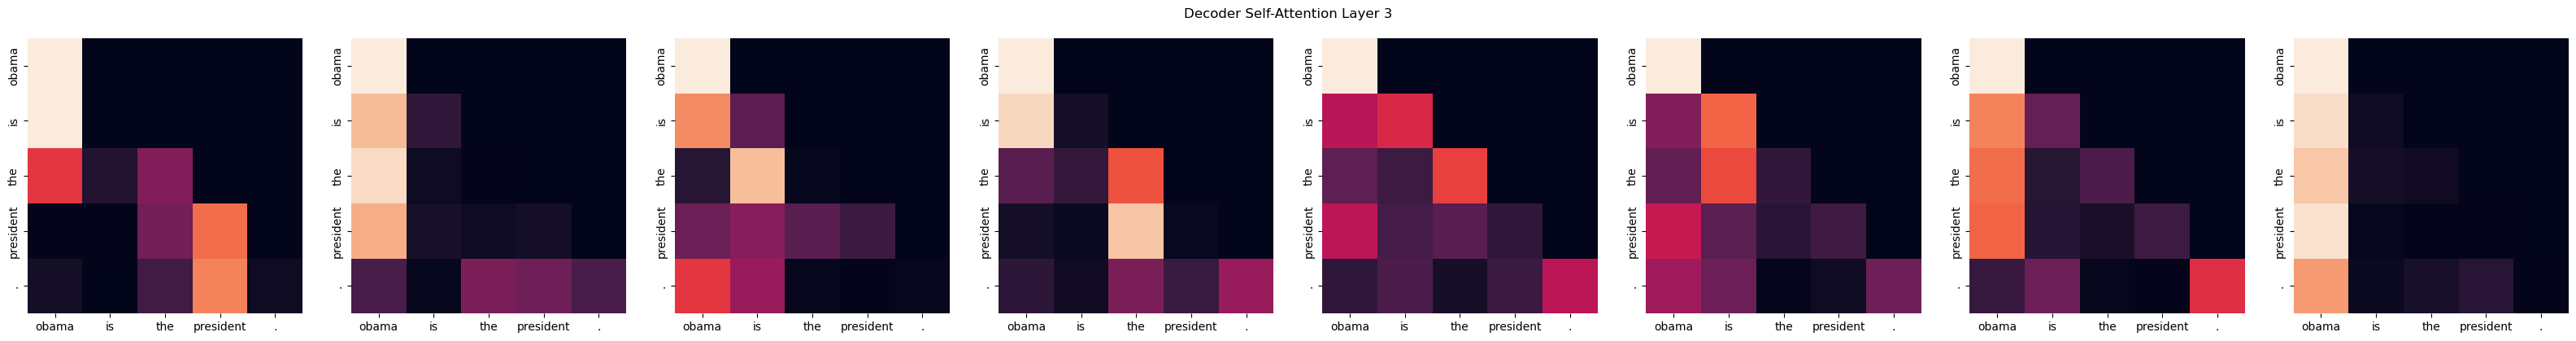

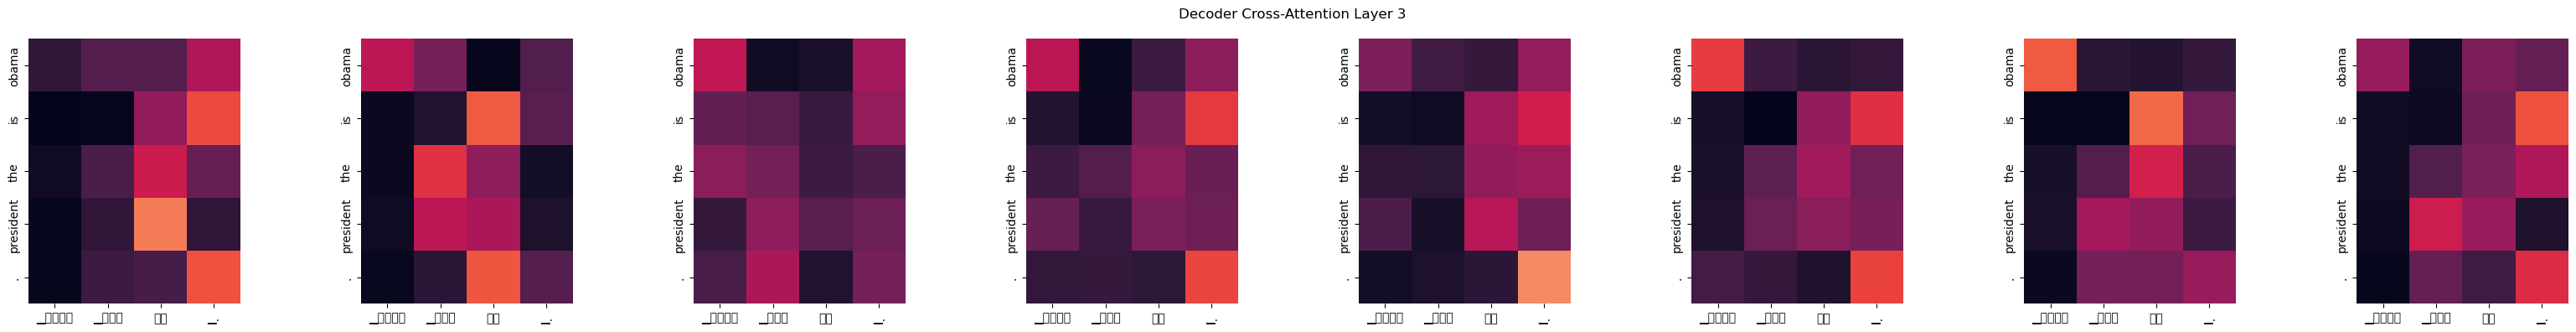

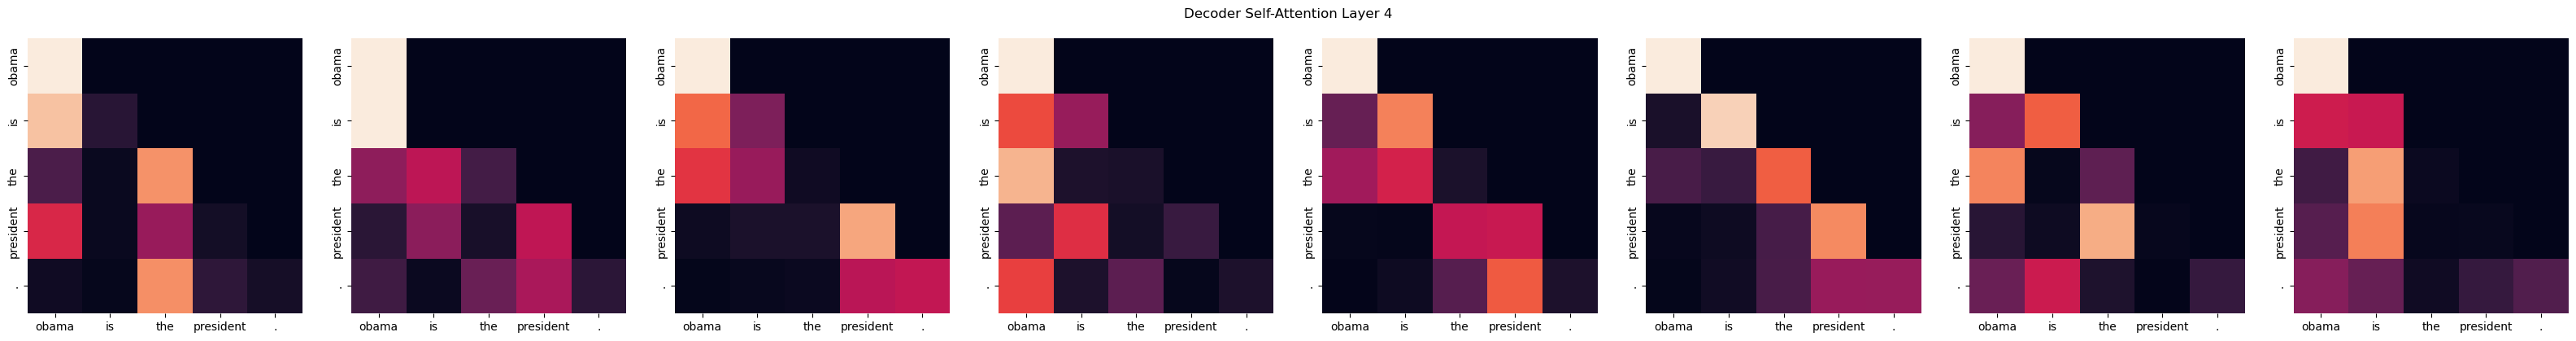

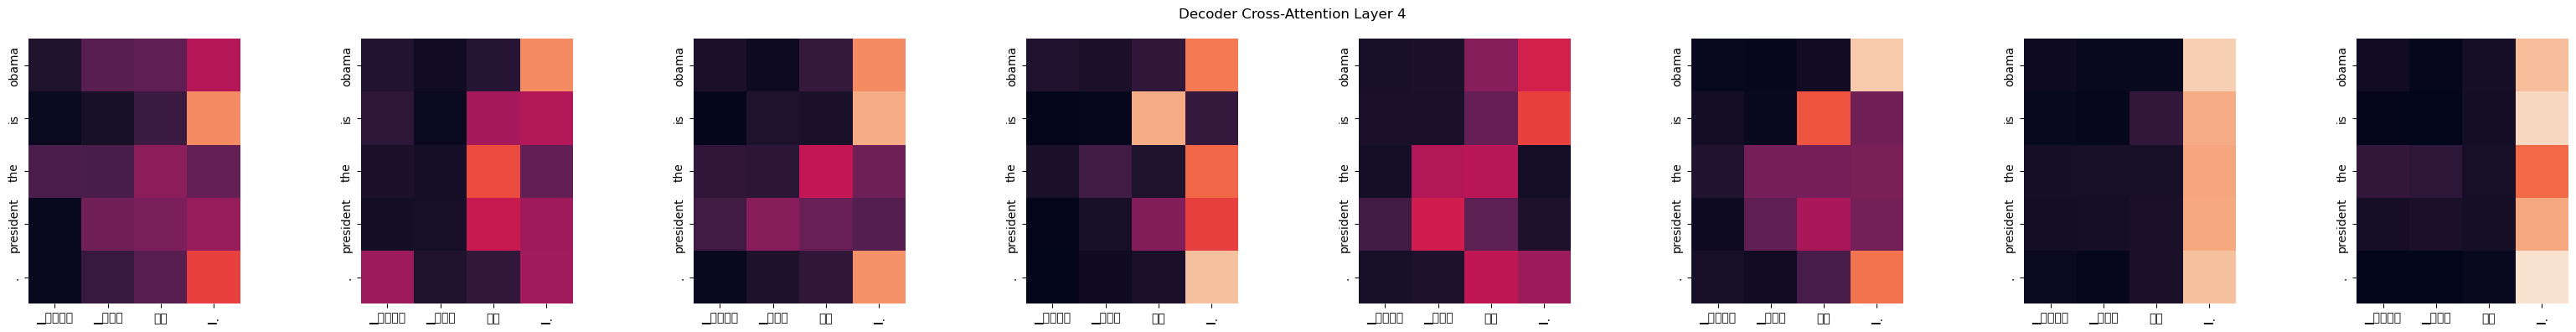

In [15]:
import seaborn
import warnings
warnings.filterwarnings("ignore")

def draw(data, ax, x, y):
    seaborn.heatmap(data.cpu().detach().float().numpy(),
                    square=True, vmin=0.0, vmax=1.0,
                    cbar=False, ax=ax, xticklabels=x, yticklabels=y)

viz_sentence = "오바마는 대통령이다."
pieces = ko_tokenizer.encode_as_pieces(preprocess_sentence(viz_sentence))
result, enc_attns, dec_attns, cross_attns = evaluate(viz_sentence)
tgt_tokens = result.split() if result else ["<empty>"]

print(f"입력: {viz_sentence}")
print(f"번역: {result}")
print()

# 인코더 self-attention
for layer in range(N_LAYERS):
    fig, axs = plt.subplots(1, N_HEADS, figsize=(4*N_HEADS, 4))
    fig.suptitle(f"Encoder Self-Attention Layer {layer+1}")
    for h in range(N_HEADS):
        draw(enc_attns[layer][0, h, :len(pieces), :len(pieces)],
             axs[h], pieces, pieces)
    plt.tight_layout()
    plt.show()

# 디코더 self-attention + cross-attention
for layer in range(N_LAYERS):
    fig, axs = plt.subplots(1, N_HEADS, figsize=(4*N_HEADS, 4))
    fig.suptitle(f"Decoder Self-Attention Layer {layer+1}")
    for h in range(N_HEADS):
        draw(dec_attns[layer][0, h, :len(tgt_tokens), :len(tgt_tokens)],
             axs[h], tgt_tokens, tgt_tokens)
    plt.tight_layout()
    plt.show()

    fig, axs = plt.subplots(1, N_HEADS, figsize=(4*N_HEADS, 4))
    fig.suptitle(f"Decoder Cross-Attention Layer {layer+1}")
    for h in range(N_HEADS):
        draw(cross_attns[layer][0, h, :len(tgt_tokens), :len(pieces)],
             axs[h], pieces, tgt_tokens)
    plt.tight_layout()
    plt.show()